## Imports

In [1]:
from keras import layers, optimizers, Input, Model, callbacks, applications
from keras.models import load_model
import keras
from methods.load_data import load_ucsf
from methods.visualisation import plot_training_history, plot_augmentation

IMAGE_SIZE = 128

c:\Users\GGPC\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Get dataset

In [2]:
x_train, y_train, x_val, y_val, x_test, y_test = load_ucsf(debug=False, classification=True, image_size=IMAGE_SIZE)
print(f"Training shape: x_train - {x_train.shape}, y_train - {y_train.shape}")
print(f"Validation shape: x_val - {x_val.shape}, y_val - {y_val.shape}")
print(f"Testing shape: x_test - {x_test.shape}, y_test - {y_test.shape}")

loading dataset...
dataset loaded.
No data leakage of patient ids in train, validation and test splits
Training shape: x_train - (46500, 128, 128, 3), y_train - (46500,)
Validation shape: x_val - (18600, 128, 128, 3), y_val - (18600,)
Testing shape: x_test - (12555, 128, 128, 3), y_test - (12555,)


## Add Augmentation

In [3]:
#augmentation = keras.Sequential([
#    layers.RandomFlip("horizontal"),
#    layers.RandomRotation(0.02),                
#    layers.RandomTranslation(0.03, 0.03),        
#    layers.RandomZoom(0.01, interpolation="bilinear"),
#], name="augmentation")

#plot_augmentation(x_train, y_train, 4, augmentation)

## Load model

In [4]:
base_model = load_model("models/best_classification_model.keras")
base_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,701 (401.18 KB)

 Trainable params: 34,233 (133.72 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 68,468 (267.46 KB)

## Load a pretrained model

In [5]:
feature_extractor = Model(base_model.input, base_model.layers[-2].output) # Keep previous model up to flatten

backbone = applications.MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    pooling="avg"
)
backbone.trainable = False # Freeze

## Create combined model

In [6]:
inputs = Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
#x = augmentation(inputs)
x = inputs
custom_features = feature_extractor(x)
pretrained_features = backbone(layers.Rescaling(scale=2.0, offset=1.0)(x), training=False)

merged = layers.Concatenate()([custom_features, pretrained_features])
merged = layers.Dropout(0.3)(merged)
merged = layers.Dense(64, activation="relu")(merged)
outputs = layers.Dense(1, activation="sigmoid")(merged)

finetune_model = Model(inputs, outputs)
finetune_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 128, 128,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ (None, 8192)      │     26,040 │ input_layer_1[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_1… │ (None, 1280)      │  2,257,984 │ rescaling[0][0]   │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 9472)      │          0 │ functional[0][0], │
│ (Concatenate)       │                   │            │ mobilenetv2_1.00… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 9472)      │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │    606,272 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,890,361 (11.03 MB)

 Trainable params: 632,377 (2.41 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Compile model

In [7]:
finetune_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.00002),
    loss="binary_crossentropy",
    metrics=["AUC"]
)

## Baseline model AUC

In [8]:
_, baseline_val_auc = base_model.evaluate(x_val, y_val, verbose=0)
print(f"Validation AUC before fine tuning: {baseline_val_auc:.4f}")

Validation AUC before fine tuning: 0.9544


## Fit model

In [9]:
BATCH_SIZE = 32
EPOCHS = 50
STAGE1_LR = 1e-4
STAGE2_LR = 1e-5

def get_callbacks():
    return [
        callbacks.EarlyStopping(
            monitor="val_AUC",
            mode="max",
            patience=4,
            restore_best_weights=True
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_AUC",
            mode="max",
            factor=0.5,
            patience=2,
            min_lr=1e-6
        )
    ]

# keep the pretrained feature extractor and backbone frozen
for layer in finetune_model.layers:
    layer.trainable = True
feature_extractor.trainable = False
backbone.trainable = False

finetune_model.compile(
    optimizer=optimizers.Adam(learning_rate=STAGE1_LR),
    loss="binary_crossentropy",
    metrics=[keras.metrics.AUC(name="AUC")]
)

history_stage1 = finetune_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=1
)

# unfreeze the pretrained backbone 
for layer in finetune_model.layers:
    layer.trainable = True
feature_extractor.trainable = False
backbone.trainable = True

finetune_model.compile(
    optimizer=optimizers.Adam(learning_rate=STAGE2_LR),
    loss="binary_crossentropy",
    metrics=[keras.metrics.AUC(name="AUC")]
)

history_stage2 = finetune_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=1
)


Epoch 1/10
1454/1454 ━━━━━━━━━━━━━━━━━━━━ 371s 252ms/step - AUC: 0.9587 - loss: 0.2387 - val_AUC: 0.9526 - val_loss: 0.2806 - learning_rate: 1.0000e-04
Epoch 2/10
1454/1454 ━━━━━━━━━━━━━━━━━━━━ 395s 272ms/step - AUC: 0.9709 - loss: 0.1983 - val_AUC: 0.9544 - val_loss: 0.2878 - learning_rate: 1.0000e-04
Epoch 3/10
1454/1454 ━━━━━━━━━━━━━━━━━━━━ 377s 259ms/step - AUC: 0.9747 - loss: 0.1859 - val_AUC: 0.9535 - val_loss: 0.2745 - learning_rate: 1.0000e-04
Epoch 4/10
1454/1454 ━━━━━━━━━━━━━━━━━━━━ 369s 254ms/step - AUC: 0.9778 - loss: 0.1734 - val_AUC: 0.9528 - val_loss: 0.2725 - learning_rate: 1.0000e-04
Epoch 5/10
1454/1454 ━━━━━━━━━━━━━━━━━━━━ 366s 251ms/step - AUC: 0.9808 - loss: 0.1628 - val_AUC: 0.9530 - val_loss: 0.2867 - learning_rate: 5.0000e-05
Epoch 6/10
1454/1454 ━━━━━━━━━━━━━━━━━━━━ 361s 248ms/step - AUC: 0.9820 - loss: 0.1568 - val_AUC: 0.9530 - val_loss: 0.2707 - learning_rate: 5.0000e-05
Epoch 1/50
1454/1454 ━━━━━━━━━━━━━━━━━━━━ 1099s 743ms/step - AUC: 0.9723 - loss: 0.1930 

## Plot training and validation history

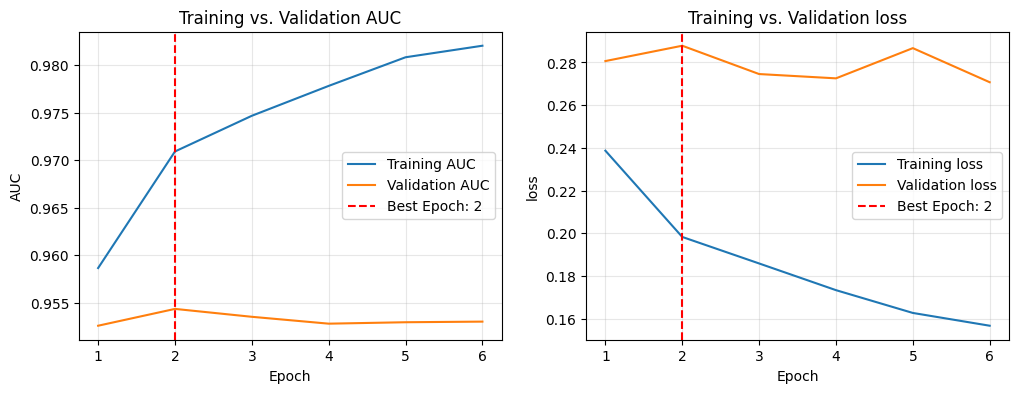

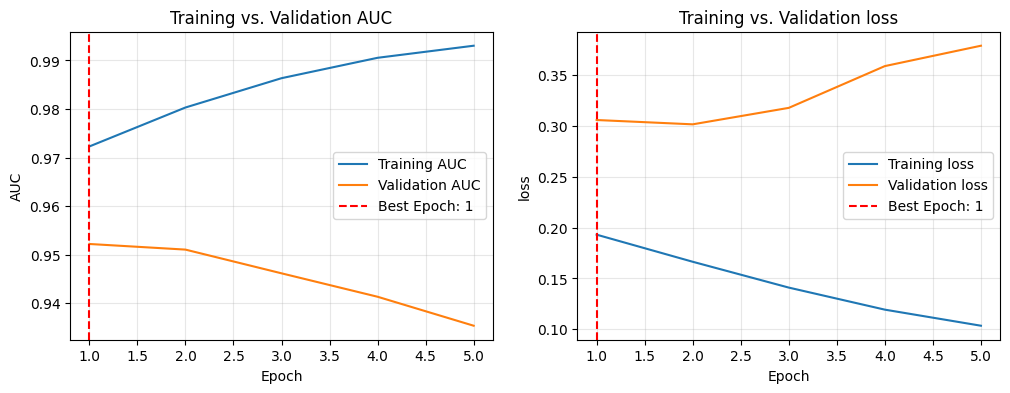

In [10]:
plot_training_history(history_stage1, "AUC", "loss")
plot_training_history(history_stage2, "AUC", "loss")

## Evaluate model

In [11]:
finetune_model.save("models/finetuned_classification_model.keras")

_, final_val_auc = finetune_model.evaluate(x_val, y_val, verbose=0)
print(f"Validation AUC: {baseline_val_auc:.4f} -> {final_val_auc:.4f}")

loss, auc = finetune_model.evaluate(x_test, y_test)
print(f"Test loss: {loss:.4f}, Test AUC: {auc:.4f}  (original: 0.9544)")

Validation AUC: 0.9544 -> 0.9522
393/393 ━━━━━━━━━━━━━━━━━━━━ 56s 142ms/step - AUC: 0.9480 - loss: 0.3128
Test loss: 0.3128, Test AUC: 0.9480  (original: 0.9544)
